<a href="https://colab.research.google.com/github/r-karra/learn-quantum-computing/blob/main/your_first_quantum_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Qiskit implimentation

In [2]:
!uv pip install qiskit[visualization] qiskit-ibm-runtime qiskit-aer

# Core qiskit imports
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# IBM Runtime specific imports
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService

Using Python 3.12.13 environment at: /usr
Checked 3 packages in 87ms


/usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(


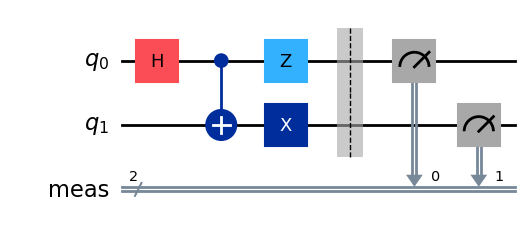

In [3]:
# Import qiskit primitives
from qiskit import QuantumCircuit
import numpy as np

# Make state
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(0)

# Measure state
qc.measure_all()
qc.draw('mpl')

# Optimize

In [5]:
from google.colab import userdata
from qiskit_ibm_runtime import QiskitRuntimeService

# Retrieve the token from Colab Secrets
try:
    api_token = userdata.get('IBMQ_TOKEN')
    service = QiskitRuntimeService(
        channel="ibm_quantum_platform",
        token=api_token
    )
    print("IBM Quantum service initialized successfully.")
except userdata.SecretNotFoundError:
    print("Error: 'IBMQ_TOKEN' not found in Colab Secrets. Please add it via the 🔑 icon in the sidebar.")
except Exception as e:
    print(f"An error occurred during authentication: {e}")

qiskit_runtime_service._discover_account:WARNING:2026-04-25 07:17:45,239: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-04-25 07:17:48,450: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


IBM Quantum service initialized successfully.


In [14]:
# backend = service.least_busy(operational=True, simulator=False, min_num_quits=12)
backend = service.backend("ibm_fez")
print(f"Selected backend: {backend.name}")

qiskit_runtime_service.backends:WARNING:2026-04-25 07:35:54,797: Using instance: open-instance, plan: open


Selected backend: ibm_fez


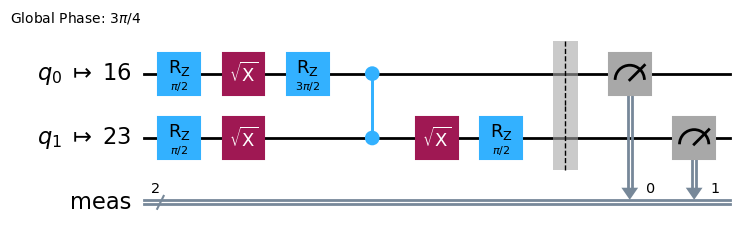

In [15]:
# Transpile the circuit and optimize for running on the quantum computer selected.
# Step 2: Transpile

from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

qc_isa.draw("mpl")

# Execute

In [16]:
# Load the Runtime primitive and session
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)

In [17]:
job = sampler.run([qc_isa], shots=100)
res = job.result()

counts = res[0].data.meas.get_counts()

counts =  {'10': 53, '01': 42, '11': 2, '00': 3}


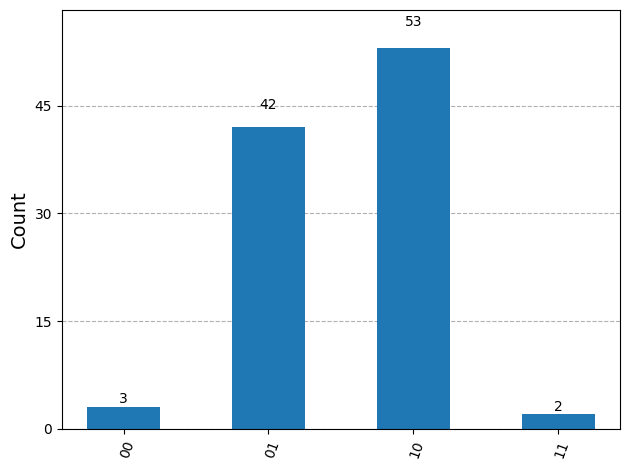

In [18]:
print("counts = ", counts)
plot_histogram(counts)

# Experiment 2: Use `Estimator` to measure the energy

1. Bell state: $(|10> - |01>) / sqrt(2)$

`Energy = -1.0234554025611193`

2. Bell state: $(|00> + |11>) / sqrt(2)$

Energy = `0.977872682359402`

3. Bell state: $(|00> - |11>) / sqrt(2)$

Energy = `0.9632493822335887`

4. Bell state: $(|10> + |01>) / sqrt(2)$

Energy = `-1.04762157152494`

In [35]:
# Import Qiskit Primitives

from qiskit.quantum_info import SparsePauliOp

# parameters
J = 1.0 # antiferromagnetic coupling (J<0)
hx = -0.5 # transverse field strength

# 1. Define the Hamiltonian H = J Z1 Z2 + hx (X1 + X2)

obs = SparsePauliOp.from_list([
    ("ZZ", J),
     ("XI", hx),
      ("IX", hx)
])
# Make a Bell state: (|10> + |01>) / sqrt(2)
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)

# # Make a Bell state: (|10> - |01>) / sqrt(2)
# qc = QuantumCircuit(2)
# qc.h(0)
# qc.cx(0, 1)
# qc.x(1)
# qc.z(0)

# # Make a Bell state: (|00> + |11>) / sqrt(2)
# qc = QuantumCircuit(2)
# qc.h(0)
# qc.cx(0, 1)

# # Make a Bell state: (|00> - |11>) / sqrt(2)
# qc = QuantumCircuit(2)
# qc.h(0)
# qc.cx(0, 1)
# qc.z(0)


# Optimize

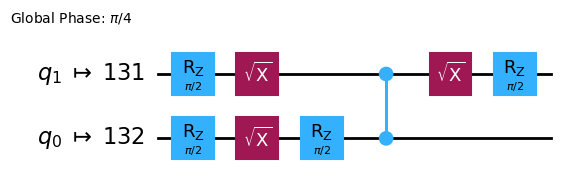

In [36]:
# Transpile the circuit and optimize for running on the quantum computer selected
# Step 2: Transpile

from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)
obs_isa = obs.apply_layout(layout=qc_isa.layout)
qc_isa.draw("mpl")

In [37]:
# Load the Runtime primitive and session

from qiskit_ibm_runtime import EstimatorV2 as Estimator

estimator = Estimator(mode=backend)

In [38]:
pubs = [(qc_isa, obs_isa)]
job = estimator.run([[qc_isa, obs_isa]])
res = job.result()

# Post-process

In [39]:
print(res[0].data.evs)

-1.04762157152494
